# Real-Time Causal Filtering

## Goal
The offline pipeline uses MNE's zero-phase, non-causal filter — it uses *future*
samples, which is impossible in real time. To run the BCI live on the PiEEG, we
need a **causal** filter that uses only current and past samples.

## The tradeoff
Causal filtering is fundamentally constrained:
- **IIR (Butterworth)** is the practical real-time choice: feedback lets it
  achieve sharp cutoffs with few coefficients and low latency, and it maps onto
  analog filter designs.
- The cost: **nonlinear (frequency-dependent) phase** — different frequencies are
  delayed by different amounts, distorting waveform shape. This is unavoidable in
  a causal filter.
- Implemented in **second-order sections (SOS)** for numerical stability, since
  high-order IIR filters can otherwise become unstable.

## What this notebook does
1. Design a causal Butterworth bandpass (8-30 Hz) in SOS form.
2. Measure its **group delay** (the latency it introduces) and see the nonlinear
   phase directly.
3. Compare its output against the offline zero-phase filter on real EEG — to see
   the time shift and distortion.
4. Measure how much classification accuracy is lost under causal, real-time-style
   filtering vs. the ideal offline pipeline.

This quantifies the real cost of moving from offline analysis to a live system.

SOS shape: (2, 6) ->  2 second-order sections


/tmp/ipykernel_10923/436474290.py:19: UserWarning: The filter's denominator is extremely small at frequencies [0.000], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), w=2048, fs=FS)


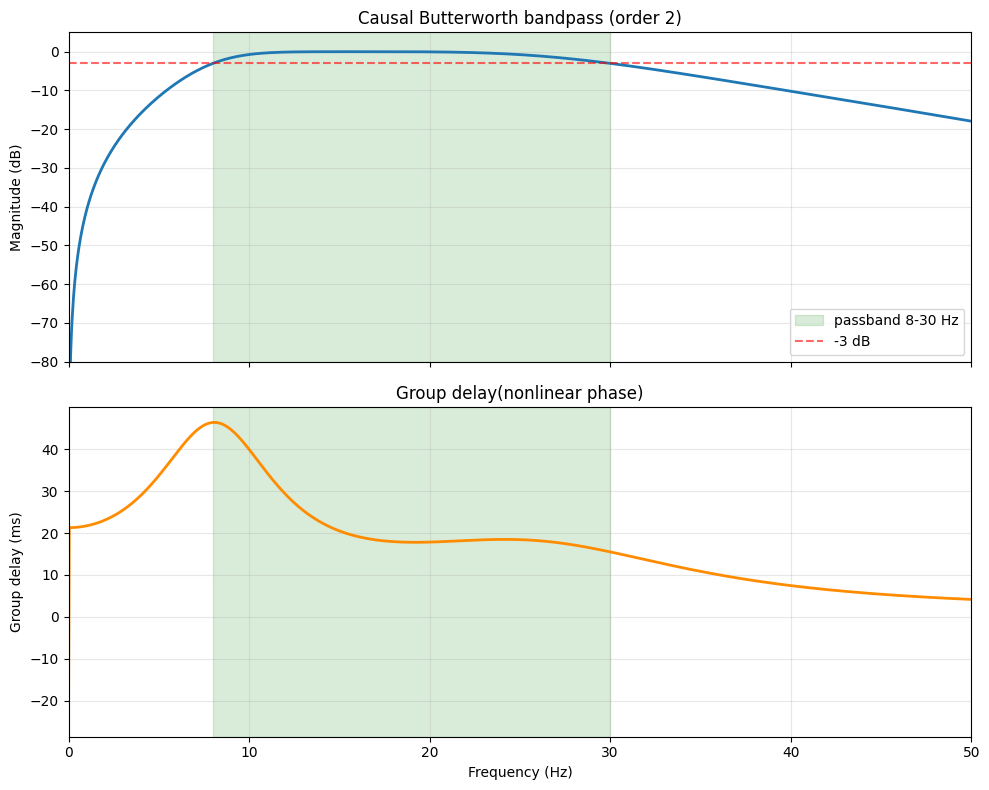

Group delay in passband: mean 22.7 ms, range 15.5-46.4 ms


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

FS = 160.0          # PhysioNet sample rate (your PiEEG will differ — we'll parameterize later)
LOW, HIGH = 8.0, 30.0
ORDER = 2           # filter order — start modest

# Design a causal Butterworth bandpass in SOS form (numerically stable)
sos = signal.butter(ORDER, [LOW, HIGH], btype='bandpass', fs=FS, output='sos')
print("SOS shape:", sos.shape, "-> ", sos.shape[0], "second-order sections")

# Frequency response
w, h = signal.freqz_sos(sos, worN=2048, fs=FS)

# Group delay: how much each frequency gets delayed (in samples, then ms)
# Convert SOS -> transfer function for group_delay
b, a = signal.sos2tf(sos)
w_gd, gd = signal.group_delay((b, a), w=2048, fs=FS)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(w, 20*np.log10(np.abs(h) + 1e-12), linewidth=2)
ax1.axvspan(LOW, HIGH, alpha=0.15, color='green', label='passband 8-30 Hz')
ax1.axhline(-3, color='red', linestyle='--', alpha=0.6, label='-3 dB')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title(f'Causal Butterworth bandpass (order {ORDER})')
ax1.set_ylim(-80, 5); ax1.legend(); ax1.grid(alpha=0.3)

gd_ms = gd / FS * 1000.0
ax2.plot(w_gd, gd_ms, linewidth=2, color='darkorange')
ax2.axvspan(LOW, HIGH, alpha=0.15, color='green')
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Group delay (ms)')
ax2.set_title('Group delay(nonlinear phase)')
ax2.set_xlim(0, 50); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Report delay within the passband
mask = (w_gd >= LOW) & (w_gd <= HIGH)
print(f"Group delay in passband: mean {gd_ms[mask].mean():.1f} ms, "
      f"range {gd_ms[mask].min():.1f}-{gd_ms[mask].max():.1f} ms")